# srp PCA on ImageNet Activations with imgANN

This notebook extracts ImageNet validation activations from an ANN through the local `imgANN` interface and fits `sklearn.decomposition.IncrementalPCA` without loading all activations into memory at once.

## Setup

In [83]:
from pathlib import Path
import gc
import json
import os
import random
import sys
from dataclasses import asdict, dataclass, field
from datetime import datetime

import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import yaml
from sklearn.decomposition import IncrementalPCA
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageNet
from tqdm.auto import tqdm

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["useful_stuff_path"])
sys.path.append(paths["src_path"])

from useful_stuff.image_processing.computational_models import imgANN, pool_features
from useful_stuff.image_processing.dim_redu import compute_img_ipca, compute_img_srp
from useful_stuff.general_utils.utils import get_device, print_wise, convert_dtype_by_name
from project_specific_utils.dataloader import imagenet_val_dataloader

## Configuration

In [106]:
@dataclass
class Cfg:
    # Model options passed to imgANN.
    model_name: str = "dino_v3_l"
    pkg: str = "hf"
    trust_remote_code: bool = False
    image_size: int = 384
    pooling: str = "all"
    n_pca_components: int = 10
    n_srp_components: int = 1000
    batch_size: int = 10
    target_layer: str = field(default_factory=lambda: ['layer.0.mlp.down_proj',])
    # default args 
    weights_type: str | None = "DEFAULT"
    repo_url: str | None = "facebook/dinov3-vitl16-pretrain-lvd1689m"
    revision: str | None = None
    attn_implementation: str | None = "sdpa"
    dtype: str = "float32"
    

cfg = Cfg()
device = get_device()

## Model Initialization

In [110]:
ann = imgANN(
    model_name=cfg.model_name,
    pkg=cfg.pkg,
    img_size=cfg.image_size,
    pooling=cfg.pooling,  # keep raw activations; postprocess them below in a model-agnostic way.
    weights_type=cfg.weights_type,
    dtype=torch.float32,
    attn_implementation=cfg.attn_implementation,
    repo_url=cfg.repo_url,
    revision=cfg.revision,
    trust_remote_code=cfg.trust_remote_code,
)

print(ann)
features_dict, hook_handles = ann.create_forward_hook(cfg.target_layer)

19:16:42 - device being used: mps
ANN(model=dino_v3_l, pkg=hf, pooling=all, device=mps, img_size=384)


## srp PCA Fitting

In [101]:
dataset, loader = imagenet_val_dataloader(paths, cfg.image_size, cfg.batch_size)

In [102]:
# n_features = np.prod(ann.get_layer_output_shape(cfg.target_layer))
# # TODO decide what to do with the projection of layers that have D <= d_srp ... 
# cfg.n_srp_components = min(n_features, cfg.n_srp_components)
# cfg.n_pca_components = min(cfg.n_pca_components, cfg.n_srp_components) 

In [103]:
# from sklearn.random_projection import SparseRandomProjection
# from sklearn.decomposition import PCA
# tot_f = []
# srp_obj = SparseRandomProjection(
#     n_components=cfg.n_srp_components,
#     random_state=0,
# )
# num_type = convert_dtype_by_name(ann.dtype, "numpy")
# pca_obj = PCA(n_components=cfg.n_pca_components) # extend this to multiple layers at once
# srp_obj.fit(np.zeros((1, n_features), dtype=num_type)) # extend this to multiple layers at once
# tot_features_list = {layer: [] for layer in ann.handles.keys()}

# for idx, (images, _) in enumerate(loader):

#     images = images.to(device)
#     ann.model(images)
    
#     for layer_name, features in ann.features.items():
#         f = features.detach().cpu().numpy()
#         print("f extracted", f.shape)
#         f = srp_obj.transform(f)
#         tot_features_list[layer_name].append(f)
#         ann.features[layer_name] = None
#     print("f transformed", f.shape)
#     tot_f.append(f)
# tot_f = np.concatenate(tot_f, axis=0)
# print("total", tot_f.shape)
# pca_obj.fit(tot_f)

In [79]:
# import time
# def compute_img_srp(ann: imgANN, loader: DataLoader, srps: dict[str: SparseRandomProjection], device: torch, rank=0):
#     f_redu = {l: [] for l in srps.keys()}
#     with torch.no_grad():
#         # Forward each image batch and let imgANN hooks collect target-layer features.
#         for idx, (images, _) in enumerate(loader):
#             if idx > 5: # TODO remove this
#                 break
#             st_forw = time.time()
#             images = images.to(device)
#             ann.model(images)
#             end_forw = time.time()
#             print_wise(f"forward took {end_forw - st_forw}", rank=rank)
#             # Update each layer's iPCA with the current batch of activations.
#             for layer, features in ann.features.items():
#                 st_srp = time.time()
#                 features = features.detach().cpu().numpy()
#                 print_wise(f"initial features shape {features.shape}")
#                 f_redu[layer].append(srps[layer].transform(features))
#                 end_srp = time.time()
#                 print_wise(f"srp transform {layer} took {end_srp - st_srp}\n shape {f_redu[layer][-1].shape}", rank=rank)
#             print_wise(f"Computed batch {idx}/{len(loader)-1} of {ann.model_name}: {list(srps.keys())}", rank=rank)
#     # concatenate the list
#     for layer in f_redu.keys():
#         f_redu[layer] = np.concatenate(f_redu[layer], axis=0)
#         print_wise(f"tot shape {layer} {f_redu[layer].shape}")
#     return f_redu
# # EOF 

In [ ]:
from sklearn.random_projection import SparseRandomProjection
from sklearn.decomposition import PCA
import gc
import time 


def save_imagenet_val_pca_srp(paths, model_name, layer_name, n_srp_components, n_pca_components, pooling):
    save_dir = Path(paths["data_path"]) / "models" / "imagenet_components"
    file_name = f"{model_name}_{layer_name}_imagenet_val_{n_srp_components}_to_{n_pca_components}_srp_to_pca_components_{pooling}pool.pkl"
    save_path = save_dir / file_name
    return save_path
# EOF

def save_imagenet_val_srp(paths, model_name, layer_name, n_srp_components, pooling):
    save_dir = Path(paths["data_path"]) / "models" / "imagenet_components"
    file_name = f"{model_name}_{layer_name}_imagenet_val_{n_srp_components}_srp_components_{pooling}pool.pkl"
    save_path = save_dir / file_name
    return save_path
# EOF


def srp_pca_imagenet_wrapper(paths, rank, target_layers, ann, loader, n_srp_components, n_pca_components, device=get_device()):
    # Build all expected output paths and keep only layers whose files do not exist yet.
    save_paths_pca = {
        layer: save_imagenet_val_pca_srp(paths, ann.model_name, layer, n_srp_components, n_pca_components, ann.pooling)
        for layer in target_layers
    }
    save_paths_srp = {
        layer: save_imagenet_val_srp(paths, ann.model_name, layer, n_srp_components, ann.pooling)
        for layer in target_layers
    }
    missing_layers = [layer for layer in target_layers if not save_paths_pca[layer].exists()]
    existing_layers = [layer for layer in target_layers if save_paths_pca[layer].exists()]

    if existing_layers:
        print_wise(f"Skipping existing {ann.model_name} layers: {', '.join(existing_layers)}", rank=rank)
    if not missing_layers:
        print_wise(f"All requested {ann.model_name} srp-PCA files already exist; skipping srp-PCA.", rank=rank)
        return {}

    # Register hooks only for layers that still need to be computed.
    ann.features = {}
    ann.create_forward_hook(layer_names=missing_layers)
    n_features_per_layer = {layer: int(np.prod(ann.get_layer_output_shape(layer))) for layer in missing_layers}
    # Create one iPCA object per missing layer, capped by that layer's feature dimensionality.
    srps = {
        layer: SparseRandomProjection(
            n_components=min(n_srp_components, n_features_per_layer[layer]),
        ).fit(np.zeros((1, n_features_per_layer[layer]), dtype=convert_dtype_by_name(ann.dtype, "numpy")))
        for layer in missing_layers
    }
    pcas = {
        layer: PCA(
            n_components=min(n_pca_components, np.prod(ann.get_layer_output_shape(layer))),
        )
        for layer in missing_layers
    }

    # Fit srp objects by streaming ImageNet validation activations batch by batch.
    f_redu = compute_img_srp(ann, loader, srps, device, rank=rank)
    for layer, pca in pcas.items():
        pca.fit(f_redu[layer])
    # Save only the newly fitted layer-specific iPCA objects.
    for layer in missing_layers:
        save_paths_pca[layer].parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(srps[layer], save_paths_srp[layer])
        joblib.dump(pcas[layer], save_paths_pca[layer])
        print_wise(f"SRPs saved at {save_paths_srp[layer]}", rank=rank)
        print_wise(f"PCs saved at {save_paths_pca[layer]}", rank=rank)
    return None
# EOF


In [ ]:
# srp_pca_imagenet_wrapper(paths, 0, cfg.target_layer, ann, loader, cfg.n_srp_components, cfg.n_pca_components,  device=get_device())

12:44:43 - rank 0 forward took 0.024974822998046875
12:44:43 - initial features shape (100, 193600)
12:44:43 - rank 0 srp transform features.0 took 0.22979497909545898
 shape (100, 1000)
12:44:43 - rank 0 Computed batch 0/499 of alexnet: ['features.0']
12:44:44 - rank 0 forward took 0.003290891647338867
12:44:44 - initial features shape (100, 193600)
12:44:44 - rank 0 srp transform features.0 took 0.28699493408203125
 shape (100, 1000)
12:44:44 - rank 0 Computed batch 1/499 of alexnet: ['features.0']
12:44:44 - rank 0 forward took 0.0042340755462646484
12:44:44 - initial features shape (100, 193600)
12:44:44 - rank 0 srp transform features.0 took 0.2842140197753906
 shape (100, 1000)
12:44:44 - rank 0 Computed batch 2/499 of alexnet: ['features.0']
12:44:45 - rank 0 forward took 0.003826141357421875
12:44:45 - initial features shape (100, 193600)
12:44:45 - rank 0 srp transform features.0 took 0.2814452648162842
 shape (100, 1000)
12:44:45 - rank 0 Computed batch 3/499 of alexnet: ['fe

In [28]:
# srps = {layer: srp_obj for layer in cfg.target_layer}
# compute_img_srp(ann, loader, srps, device);

In [107]:
pca_p = "/Users/tizianocausin/sd_local/models/imagenet_components/dino_v3_l_layer.0.mlp.down_proj_imagenet_val_10000_to_1000_srp_to_pca_components_allpool.pkl"
pca_obj =joblib.load(pca_p)
srp_p = "/Users/tizianocausin/sd_local/models/imagenet_components/dino_v3_l_layer.0.mlp.down_proj_imagenet_val_10000_srp_components_allpool.pkl"
srp_obj =joblib.load(srp_p)

Projecting random images:   0%|          | 0/1 [00:00<?, ?it/s]

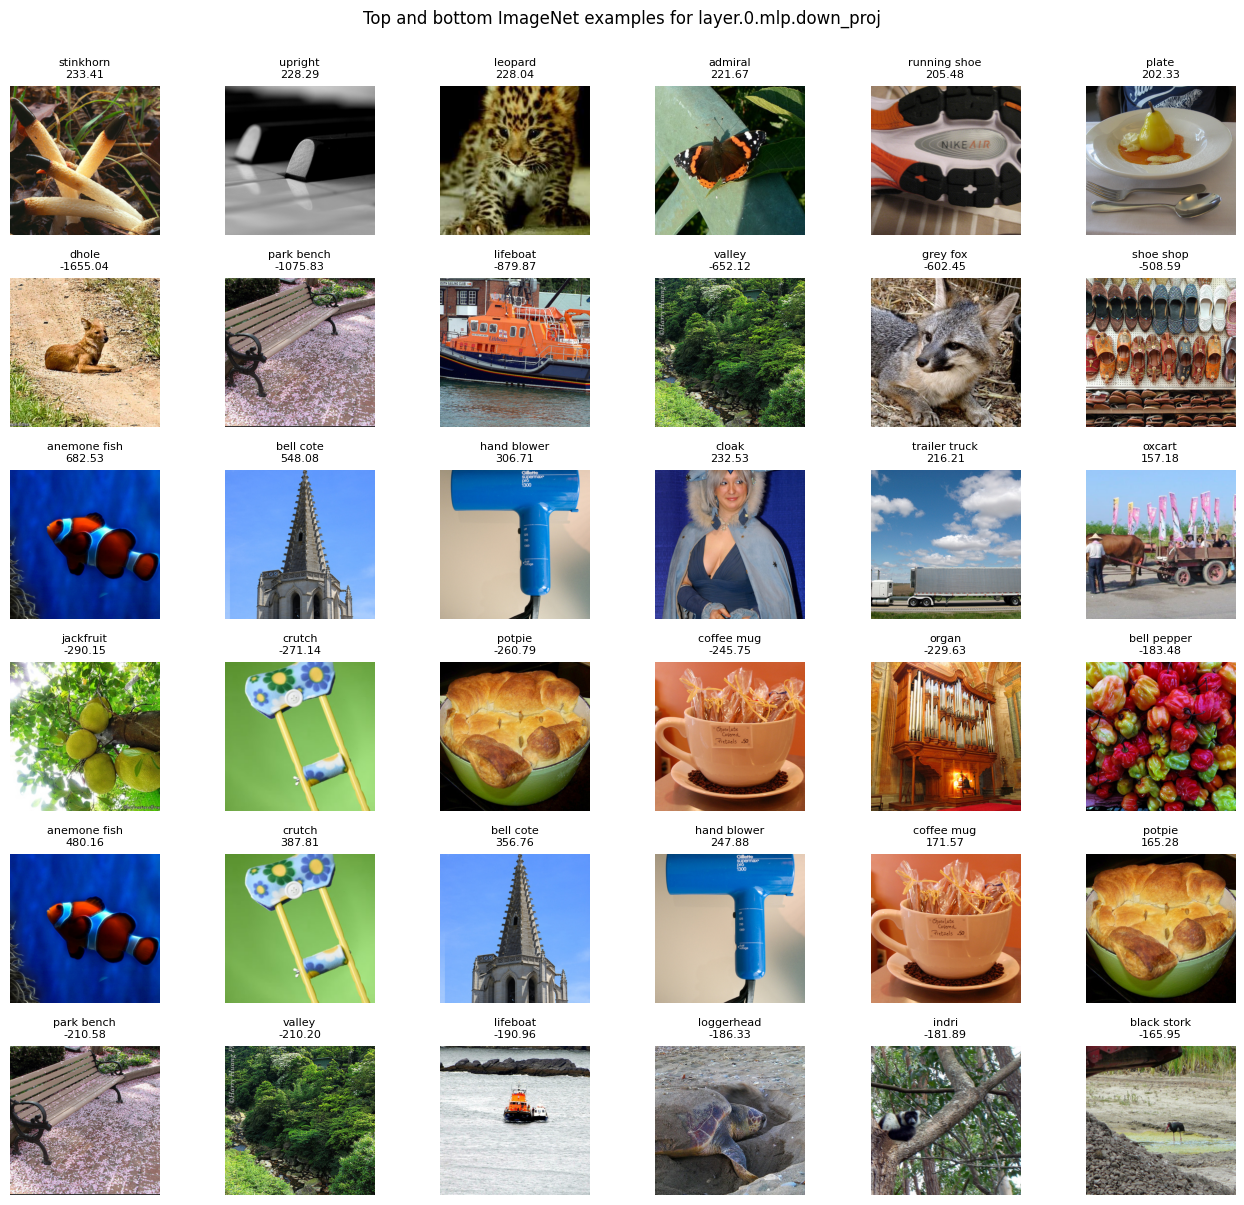

In [ ]:
sample_n = 100
n_extreme = 6
n_pcs_to_show = 3
# layer = cfg.target_layers[1]
layer = cfg.target_layer[0]

rng = np.random.default_rng(100)
viz_indices = rng.choice(len(dataset), size=min(sample_n, len(dataset)), replace=False).tolist()
viz_dataset = Subset(dataset, viz_indices)
viz_loader = DataLoader(
    viz_dataset,
    batch_size=cfg.batch_size*10,
    shuffle=False,
)

viz_images = []
viz_targets = []
viz_features = []

ann.get_model().eval()
for images, targets in tqdm(viz_loader, desc="Projecting random images"):
    viz_images.append(images.cpu())
    viz_targets.append(targets.cpu())

    images = images.to(device, non_blocking=True)
    with torch.inference_mode():
        if cfg.pkg == "hf":
            ann.model(pixel_values=images)
        else:
            ann.model(images)

    features = ann.features[layer].detach().float().cpu().numpy()
    viz_features.append(features)

viz_images = torch.cat(viz_images)
viz_targets = torch.cat(viz_targets)
viz_features = np.concatenate(viz_features, axis=0)
viz_features = srp_obj.transform(viz_features)
viz_scores = pca_obj.transform(viz_features)#ipcas[layer].transform(viz_features)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
classes = dataset.dataset.classes if isinstance(dataset, Subset) else dataset.classes

def show_image(ax, image, target, score):
    image = (image * std + mean).clamp(0, 1)
    class_names = classes[int(target)]
    label = class_names[0] if isinstance(class_names, tuple) else class_names
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(f"{label}\n{score:.2f}", fontsize=8)
    ax.axis("off")

n_pcs_to_show = min(n_pcs_to_show, viz_scores.shape[1])
fig, axes = plt.subplots(n_pcs_to_show * 2, n_extreme, figsize=(2.2 * n_extreme, 4.0 * n_pcs_to_show))
axes = np.atleast_2d(axes)

for pc_idx in range(n_pcs_to_show):
    scores = viz_scores[:, pc_idx]
    bottom_indices = np.argsort(scores)[:n_extreme]
    top_indices = np.argsort(scores)[-n_extreme:][::-1]

    axes[2 * pc_idx, 0].set_ylabel(f"PC {pc_idx + 1} top", fontsize=10)
    axes[2 * pc_idx + 1, 0].set_ylabel(f"PC {pc_idx + 1} bottom", fontsize=10)

    for col, idx in enumerate(top_indices):
        show_image(axes[2 * pc_idx, col], viz_images[idx], viz_targets[idx], scores[idx])
    for col, idx in enumerate(bottom_indices):
        show_image(axes[2 * pc_idx + 1, col], viz_images[idx], viz_targets[idx], scores[idx])

gc.collect()
torch.cuda.empty_cache()
fig.suptitle(f"Top and bottom ImageNet examples for {layer}", y=1.0)
plt.tight_layout()
plt.show()